In [ ]:
!pip install "agnpy==0.4.0"
!pip install gammapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 851.7/851.7 kB 26.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import astropy.units as u
from astropy.constants import m_e
from astropy.coordinates import Distance
import matplotlib.pyplot as plt
from IPython.display import Image

In [ ]:
from agnpy.spectra import PowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton
from agnpy.utils.plot import plot_sed, load_mpl_rc


# Component wise plots: The accretion disk and the dusty torus

 ## The functional form?

In [6]:
import numpy as np
import astropy.units as u
import astropy.constants as const
from agnpy.targets import SSDisk, RingDustTorus

# quantities defining the disk
M_BH = 1.2 * 1e9 * const.M_sun
L_disk = 2 * 1e46 * u.Unit("erg s-1")
eta = 1 / 12
R_g = 1.77 * 1e14 * u.cm
R_in = 6 * R_g
R_out = 200 * R_g

#disk = SSDisk(M_BH, L_disk, eta, R_in, R_out)
disk = SSDisk(M_BH, L_disk, eta, 6, 200, R_g_units=True)
print(disk)

* Shakura Sunyaev accretion disk:
 - M_BH (central black hole mass): 2.39e+42 g
 - L_disk (disk luminosity): 2.00e+46 erg / s
 - eta (accretion efficiency): 8.33e-02
 - dot(m) (mass accretion rate): 2.67e+26 g / s
 - R_in (disk inner radius): 1.06e+15 cm
 - R_out (disk inner radius): 3.54e+16 cm


In [8]:
dt   = RingDustTorus(L_disk, xi_dt=0.1, T_dt=1e3 * u.K)
print (dt)

* Ring Dust Torus:
 - L_disk (accretion disk luminosity): 2.00e+46 erg / s
 - xi_dt (fraction of the disk radiation reprocessed by the torus): 1.00e-01
 - T_dt (temperature of the dust torus): 1.00e+03 K
 - R_dt (radius of the torus): 1.57e+19 cm



/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in expm1
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in expm1
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-package

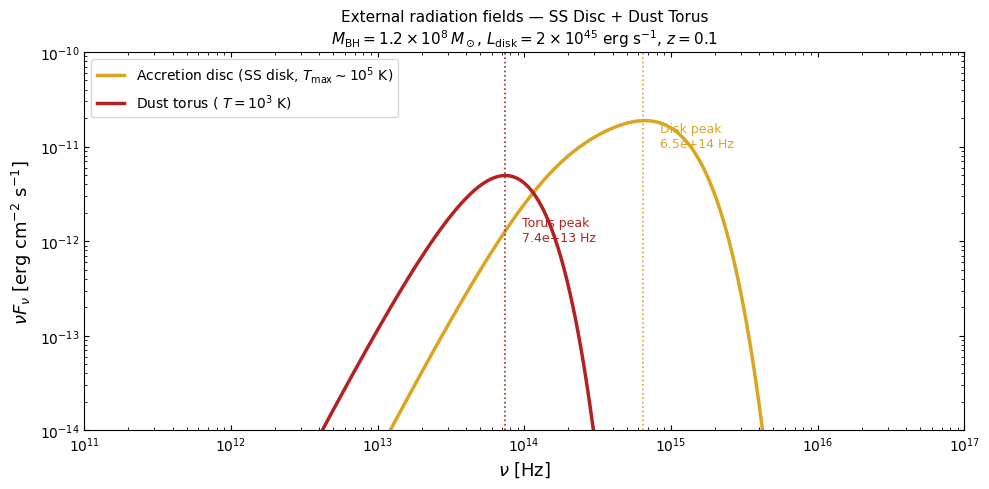

In [9]:
import numpy as np
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt
from agnpy.targets import SSDisk, RingDustTorus

# ── parameters ─────────────────────────────────────────────
M_BH   = 1.2e8 * const.M_sun
L_disk = 2e45  * u.Unit("erg s-1")
eta    = 1/12
R_g    = 1.77e14 * u.cm
R_in   = 6   * R_g
R_out  = 200 * R_g
z      = 0.1

# ── objects ────────────────────────────────────────────────
disk = SSDisk(M_BH, L_disk, eta, R_in, R_out)
dt   = RingDustTorus(L_disk, xi_dt=0.1, T_dt=1e3 * u.K)
nu = np.logspace(11, 17, 300) * u.Hz

# ── SEDs ───────────────────────────────────────────────────
disk_sed = disk.sed_flux(nu, z)
dt_sed   = dt.sed_flux(nu, z)

# ── plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.loglog(nu.value, disk_sed.value,
          lw=2.5, color='goldenrod',
          label=r'Accretion disc (SS disk, $T_{\rm max} \sim 10^5$ K)')

ax.loglog(nu.value, dt_sed.value,
          lw=2.5, color='firebrick',
          label=r'Dust torus ( $T = 10^3$ K)')

# mark the two peaks explicitly
nu_disk_peak = nu.value[np.argmax(disk_sed.value)]
nu_dt_peak   = nu.value[np.argmax(dt_sed.value)]
ax.axvline(nu_disk_peak, ls=':', color='goldenrod', lw=1.2)
ax.axvline(nu_dt_peak,   ls=':', color='firebrick',  lw=1.2)
ax.text(nu_disk_peak * 1.3, 1e-11,
        f'Disk peak\n{nu_disk_peak:.1e} Hz', color='goldenrod', fontsize=9)
ax.text(nu_dt_peak  * 1.3, 1e-12,
        f'Torus peak\n{nu_dt_peak:.1e} Hz',  color='firebrick',  fontsize=9)

ax.set_xlabel(r'$\nu$ [Hz]', fontsize=13)
ax.set_ylabel(r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]', fontsize=13)
ax.set_xlim(1e11, 1e17)
ax.set_ylim(1e-14, 1e-10)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(fontsize=10, loc='upper left')
ax.set_title(
    'External radiation fields — SS Disc + Dust Torus\n'
    r'$M_{\rm BH}=1.2\times10^8\,M_\odot$, '
    r'$L_{\rm disk}=2\times10^{45}$ erg s$^{-1}$, $z=0.1$',
    fontsize=11
)
plt.tight_layout()
plt.show()

In [11]:
from astropy.constants import c as c_light

# ── use nu_therm (300 points) which is what disk/torus were computed on
wav      = (c_light.to("cm/s").value / nu_therm.value) * 1e8  # Angstroms
wav_disk_peak = (c_light.to("cm/s").value / nu_disk_peak) * 1e8
wav_dt_peak   = (c_light.to("cm/s").value / nu_dt_peak)   * 1e8

# ── sort low→high wavelength ───────────────────────────────────
idx         = np.argsort(wav)
wav_sorted  = wav[idx]
disk_sorted = disk_sed.value[idx]
dt_sorted   = dt_sed.value[idx]

# ── plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.loglog(wav_sorted, disk_sorted,
          lw=2.5, color='goldenrod',
          label=r'Accretion disc (SS disk, $T_{\rm max}\sim10^5$ K)')
ax.loglog(wav_sorted, dt_sorted,
          lw=2.5, color='firebrick',
          label=r'Dust torus ($T=10^3$ K)')

ax.axvline(wav_disk_peak, ls=':', color='goldenrod', lw=1.2)
ax.axvline(wav_dt_peak,   ls=':', color='firebrick',  lw=1.2)

ax.text(wav_disk_peak * 0.4, 1e-11,
        f'Disc peak\n{wav_disk_peak:.0f} Å\n(UV/Optical)',
        color='goldenrod', fontsize=9, ha='center')
ax.text(wav_dt_peak * 3, 4e-12,
        f'Torus peak\n{wav_dt_peak:.2e} Å\n(mid-IR)',
        color='firebrick', fontsize=9, ha='center')

band_labels = [
    (1e2, 1e3,  'EUV'),
    (1e3, 4e3,  'UV'),
    (4e3, 7e3,  'Optical'),
    (7e3, 1e5,  'NIR'),
    (1e5, 1e7,  'Mid-IR'),
]
for lam_lo, lam_hi, lbl in band_labels:
    ax.axvspan(lam_lo, lam_hi, alpha=0.06, color='grey')
    ax.text(np.sqrt(lam_lo * lam_hi), 8e-11,
            lbl, fontsize=8, ha='center', color='dimgrey')

ax.set_xlabel(r'$\lambda$ [Å]', fontsize=13)
ax.set_ylabel(r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]', fontsize=13)
ax.set_xlim(1e2, 1e8)
ax.set_ylim(1e-14, 1e-10)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(fontsize=10, loc='lower left')
ax.set_title(
    'External radiation fields — SS Disc + Dust Torus\n'
    r'$M_{\rm BH}=1.2\times10^9\,M_\odot$, '
    r'$L_{\rm disk}=2\times10^{46}$ erg s$^{-1}$, $z=0.1$',
    fontsize=11
)
plt.tight_layout()
plt.show()

NameError: name 'nu_therm' is not defined

# Synchrotron

In [12]:
R_b = 1e16 * u.cm
V_b = 4 / 3 * np.pi * R_b ** 3
z = Distance(1e27, unit=u.cm).z
delta_D = 10
Gamma = 10
B = 1 * u.G

# electron distribution
W_e = 1e48 * u.Unit("erg")

n_e = PowerLaw.from_total_energy(
    W=W_e, V=V_b, p=2.8, gamma_min=1e2, gamma_max=1e7, mass=m_e
)

blob = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e)
# Find out what is k in power law?


In [13]:
print(blob)

* Spherical emission region
 - R_b (radius of the blob): 1.00e+16 cm
 - t_var (variability time scale): 4.13e-01 d
 - V_b (volume of the blob): 4.19e+48 cm3
 - z (source redshift): 0.07 redshift
 - d_L (source luminosity distance):1.00e+27 cm
 - delta_D (blob Doppler factor): 1.00e+01
 - Gamma (blob Lorentz factor): 1.00e+01
 - Beta (blob relativistic velocity): 9.95e-01
 - theta_s (jet viewing angle): 5.74e+00 deg
 - B (magnetic field tangled to the jet): 1.00e+00 G
 - xi (coefficient for 1st order Fermi acceleration) : 1.00e+00
* electrons energy distribution
 - power law
 - k: 9.27e+06 1 / cm3
 - p: 2.80
 - gamma_min: 1.00e+02
 - gamma_max: 1.00e+07



In [14]:

synch = Synchrotron(blob)

nu_syn = np.logspace(8, 23) * u.Hz

# let us compute a synchrotron, and a self-absorbed synchrotron SED
synch_sed = synch.sed_flux(nu_syn)


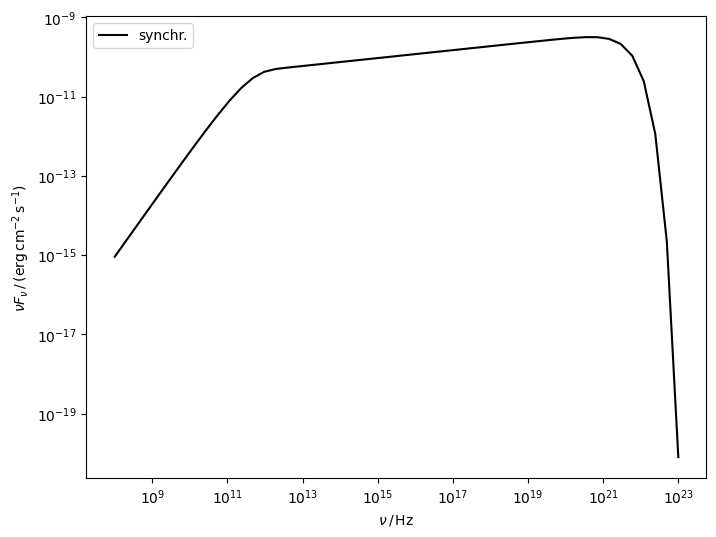

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_sed(nu_syn, synch_sed, ax=ax, color="k", label="synchr.")

plt.show()



In [ ]:
# Synchrotron self compton component

/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:66: RuntimeWarning: divide by zero encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:66: RuntimeWarning: invalid value encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)


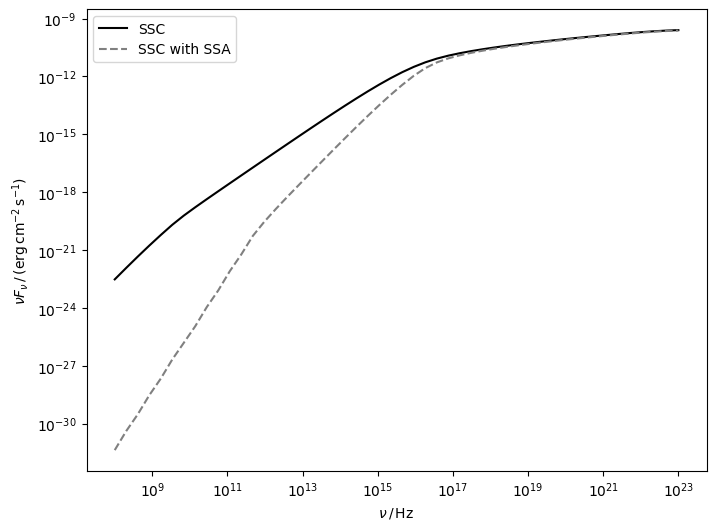

In [17]:
ssc = SynchrotronSelfCompton(blob)

# ssc over a self-absorbed synchrotron spectrum
ssc_ssa = SynchrotronSelfCompton(blob, ssa=True)
nu_ssc = np.logspace(8, 23) * u.Hz
sed_ssc = ssc.sed_flux(nu_ssc)
sed_ssc_ssa = ssc_ssa.sed_flux(nu_ssc)

fig, ax = plt.subplots(figsize=(8, 6))

plot_sed(nu_ssc, sed_ssc, color="k", label="SSC")
plot_sed(nu_ssc, sed_ssc_ssa, ls="--", color="gray", label="SSC with SSA")
plt.show()


# External Compton

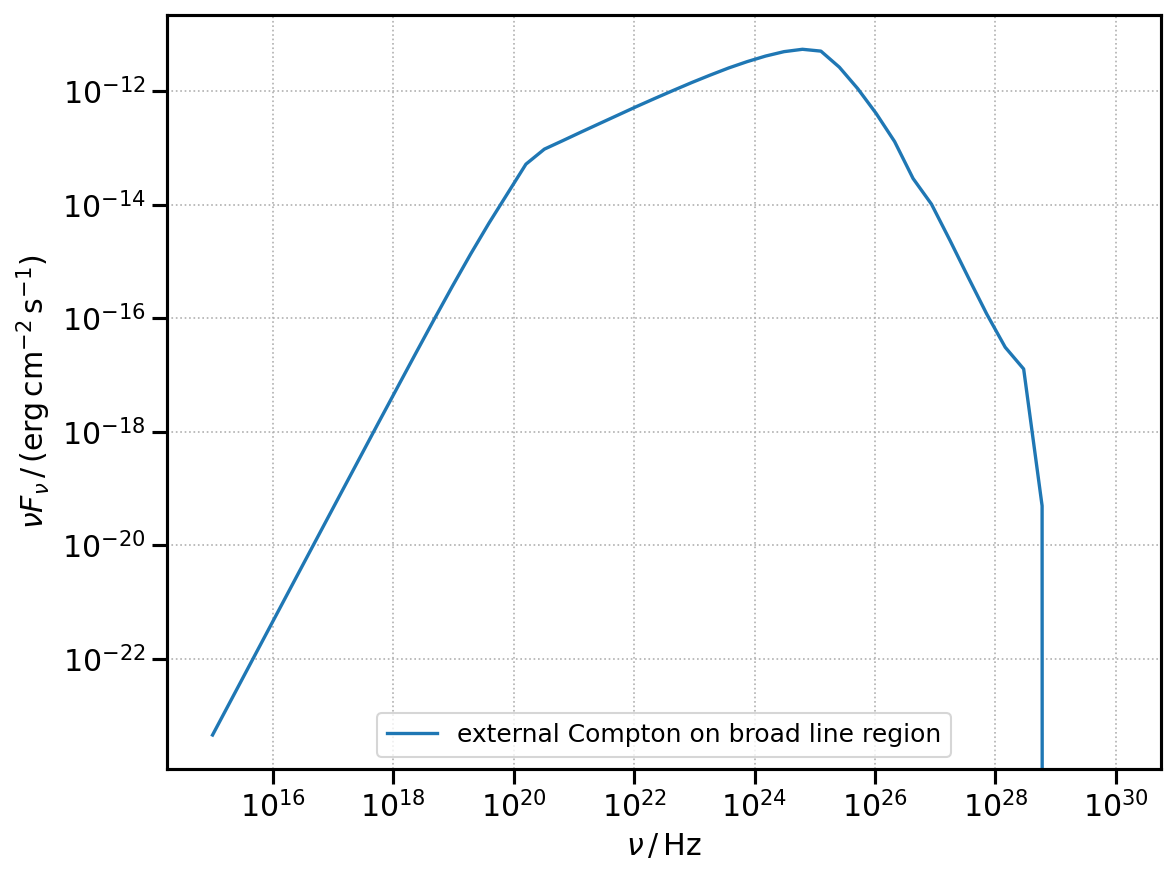

In [18]:
import numpy as np
import astropy.units as u
from astropy.constants import m_e
from agnpy.spectra import BrokenPowerLaw
from agnpy.emission_regions import Blob
from agnpy.compton import ExternalCompton
from agnpy.targets import SphericalShellBLR
from agnpy.utils.plot import plot_sed
import matplotlib.pyplot as plt
from agnpy.utils.plot import load_mpl_rc



# define the emission region and the electron distribution
R_b = 1e16 * u.cm
V_b = 4 / 3 * np.pi * R_b ** 3
z = 1
delta_D = 40
Gamma = 40
B = 0.56 * u.G

W_e = 6e45 * u.erg
n_e = BrokenPowerLaw.from_total_energy(
    W=W_e, V=V_b, p1=2.0, p2=3.5, gamma_b=1e4, gamma_min=20, gamma_max=5e7, mass=m_e
)

blob = Blob(R_b, z, delta_D, Gamma, B, n_e, gamma_e_size=500) #units?


# define the target
L_disk = 2 * 1e46 * u.Unit("erg s-1")
xi_line = 0.024 # Figure out? fraction of disk emission processeed by the BLR.
R_line = 1e17 * u.cm

blr = SphericalShellBLR(L_disk, xi_line, "Lyalpha", R_line)


# declare the external Compton process
# distance between the blob and the target
r = 2e17 * u.cm
ec = ExternalCompton(blob, blr, r)

# compute the SED over an array of frequencies
nu = np.logspace(15, 30) * u.Hz
sed = ec.sed_flux(nu)

# plot it
load_mpl_rc()
plot_sed(nu, sed, label="external Compton on broad line region")

plt.show()

/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:66: RuntimeWarning: divide by zero encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:66: RuntimeWarning: invalid value encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:67: RuntimeWarning: overflow encountered in divide
  return np.where(tau < 1e-3, 1, 3 * u / tau)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in expm1
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/

Synch max  : 3.70e-11
SSC max    : 4.84e-09
Disk max   : 4.99e-12
Torus max  : 9.62e-13
Synch peak : 3.44e+16 Hz  (log=16.5)
SSC peak   : 1.30e+25 Hz  (log=25.1)


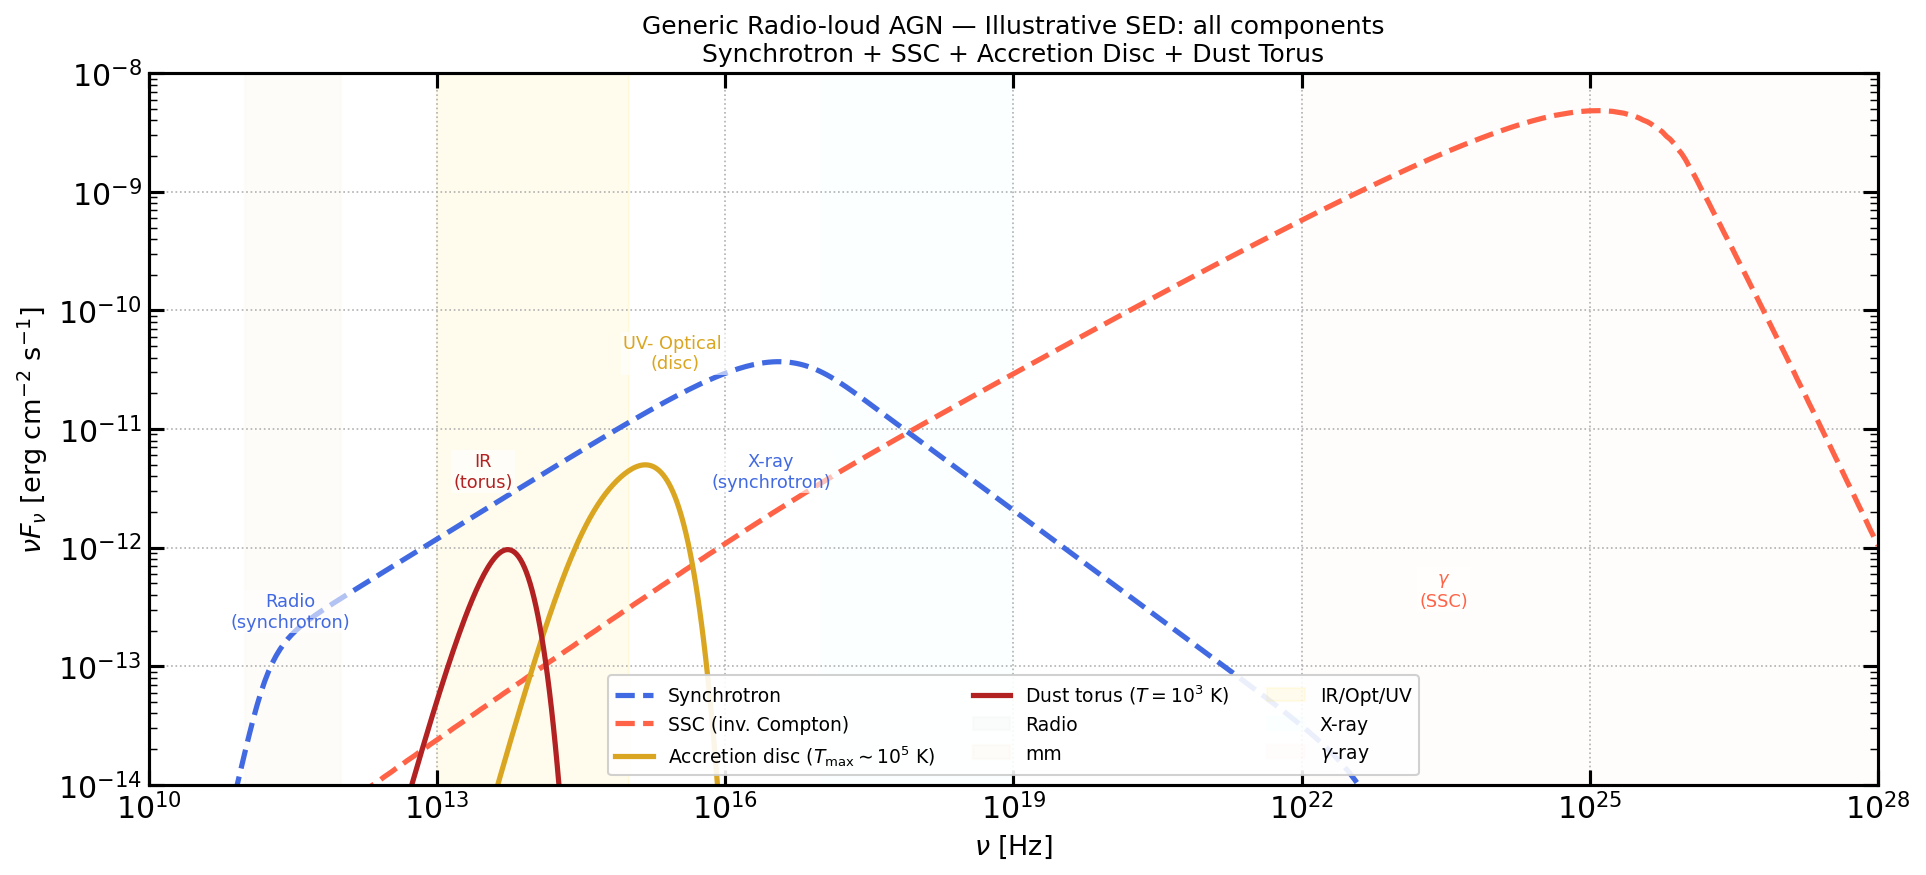

In [19]:
import numpy as np
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt

from agnpy.spectra import BrokenPowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton
from agnpy.targets import SSDisk, RingDustTorus

z = 0.5

# ── electron distribution ──────────────────────────────────
# gamma_b = 1e5 pushes synch into UV/soft-X-ray
# SSC then falls in hard X-ray / gamma-ray
n_e = BrokenPowerLaw(
    k         = 5e-5 * u.Unit("cm-3"),
    p1        = 2.0,
    p2        = 4.2,
    gamma_b   = 1e5,
    gamma_min = 1e0,
    gamma_max = 1e8,
)

# ── blob ───────────────────────────────────────────────────
# B = 0.1 G, delta_D = 15 → synch peaks ~10^16 Hz (soft X-ray)
# SSC then peaks ~10^23-24 Hz (GeV gamma-ray)
blob = Blob(
    R_b     = 1e16 * u.cm,
    z       = z,
    delta_D = 15.0,
    Gamma   = 14.0,
    B       = 0.1 * u.G,
    n_e     = n_e,
)

# ── accretion disc ─────────────────────────────────────────
M_BH   = 1e9 * const.M_sun
L_disk = 2e46 * u.Unit("erg s-1")
R_g    = 1.77e14 * u.cm
disk   = SSDisk(M_BH, L_disk, eta=1/12,
                R_in=6*R_g, R_out=200*R_g)

# ── dust torus ─────────────────────────────────────────────
dt = RingDustTorus(L_disk, xi_dt=0.1, T_dt=1e3*u.K)

# ── frequency grids ────────────────────────────────────────
nu_jet   = np.logspace(8,  28, 500) * u.Hz
nu_therm = np.logspace(11, 17, 300) * u.Hz

# ── jet SEDs ───────────────────────────────────────────────
sed_synch = Synchrotron(blob, ssa=True).sed_flux(nu_jet)
sed_ssc   = SynchrotronSelfCompton(blob).sed_flux(nu_jet)

# ── thermal SEDs ───────────────────────────────────────────
disk_sed = disk.sed_flux(nu_therm, z)
dt_sed   = dt.sed_flux(nu_therm,   z)




# ── diagnostic print — check all components are non-zero ──
print(f"Synch max  : {np.nanmax(sed_synch.value):.2e}")
print(f"SSC max    : {np.nanmax(sed_ssc.value):.2e}")
print(f"Disk max   : {np.nanmax(disk_sed.value):.2e}")
print(f"Torus max  : {np.nanmax(dt_sed.value):.2e}")

nu_pk_s = nu_jet.value[np.argmax(sed_synch.value)]
nu_pk_c = nu_jet.value[np.argmax(sed_ssc.value)]
print(f"Synch peak : {nu_pk_s:.2e} Hz  (log={np.log10(nu_pk_s):.1f})")
print(f"SSC peak   : {nu_pk_c:.2e} Hz  (log={np.log10(nu_pk_c):.1f})")

def mask(arr):
    return np.where(arr > 1e-20, arr, np.nan)

# ── plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# jet
ax.loglog(nu_jet.value, mask(sed_synch.value),
          '--', color='royalblue', lw=2.5,
          label='Synchrotron')
ax.loglog(nu_jet.value, mask(sed_ssc.value),
          '--', color='tomato', lw=2.5,
          label='SSC (inv. Compton)')

# thermal
ax.loglog(nu_therm.value, mask(disk_sed.value),
          '-', color='goldenrod', lw=2.5,
          label=r'Accretion disc ($T_{\rm max}\sim10^5$ K)')
ax.loglog(nu_therm.value, mask(dt_sed.value),
          '-', color='firebrick', lw=2.5,
          label=r'Dust torus ($T=10^3$ K)')



# ── band shading ───────────────────────────────────────────
bands = [
    (1e8,  1e10,  'lightgrey', 'Radio'),
    (1e11, 1e12,  'wheat',     'mm'),
    (1e13, 1e15,  'gold',      'IR/Opt/UV'),
    (1e17, 1e19,  'lightcyan', 'X-ray'),
    (1e22, 1e28,  'mistyrose', r'$\gamma$-ray'),
]
for nu_lo, nu_hi, col, lbl in bands:
    ax.axvspan(nu_lo, nu_hi, alpha=0.07, color=col, label=lbl)

# ── annotations ────────────────────────────────────────────
annotations = [
    (3e11,  2e-13, 'Radio\n(synchrotron)',     'royalblue'),
    (3e13, 3e-12, 'IR\n(torus)',        'firebrick'),
    (3e15, 3e-11, 'UV- Optical \n(disc)',         'goldenrod'),
    (3e16, 3e-12, 'X-ray\n(synchrotron)',     'royalblue'),
    (3e23, 3e-13, r'$\gamma$'+'\n(SSC)','tomato'),
]
for x, y, txt, col in annotations:
    ax.text(x, y, txt, fontsize=8.5, color=col,
            ha='center', va='bottom',
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

# ── formatting ─────────────────────────────────────────────
ax.set_xlabel(r'$\nu$ [Hz]', fontsize=13)
ax.set_ylabel(r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]', fontsize=13)
ax.set_xlim(1e10,  1e28)
ax.set_ylim(1e-14, 1e-8)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(fontsize=9, ncol=3, loc='lower center', framealpha=0.9)
ax.set_title(
    'Generic Radio-loud AGN — Illustrative SED: all components\n'
    r'Synchrotron + SSC + Accretion Disc + Dust Torus',
    fontsize=12
)
plt.tight_layout()
plt.show()

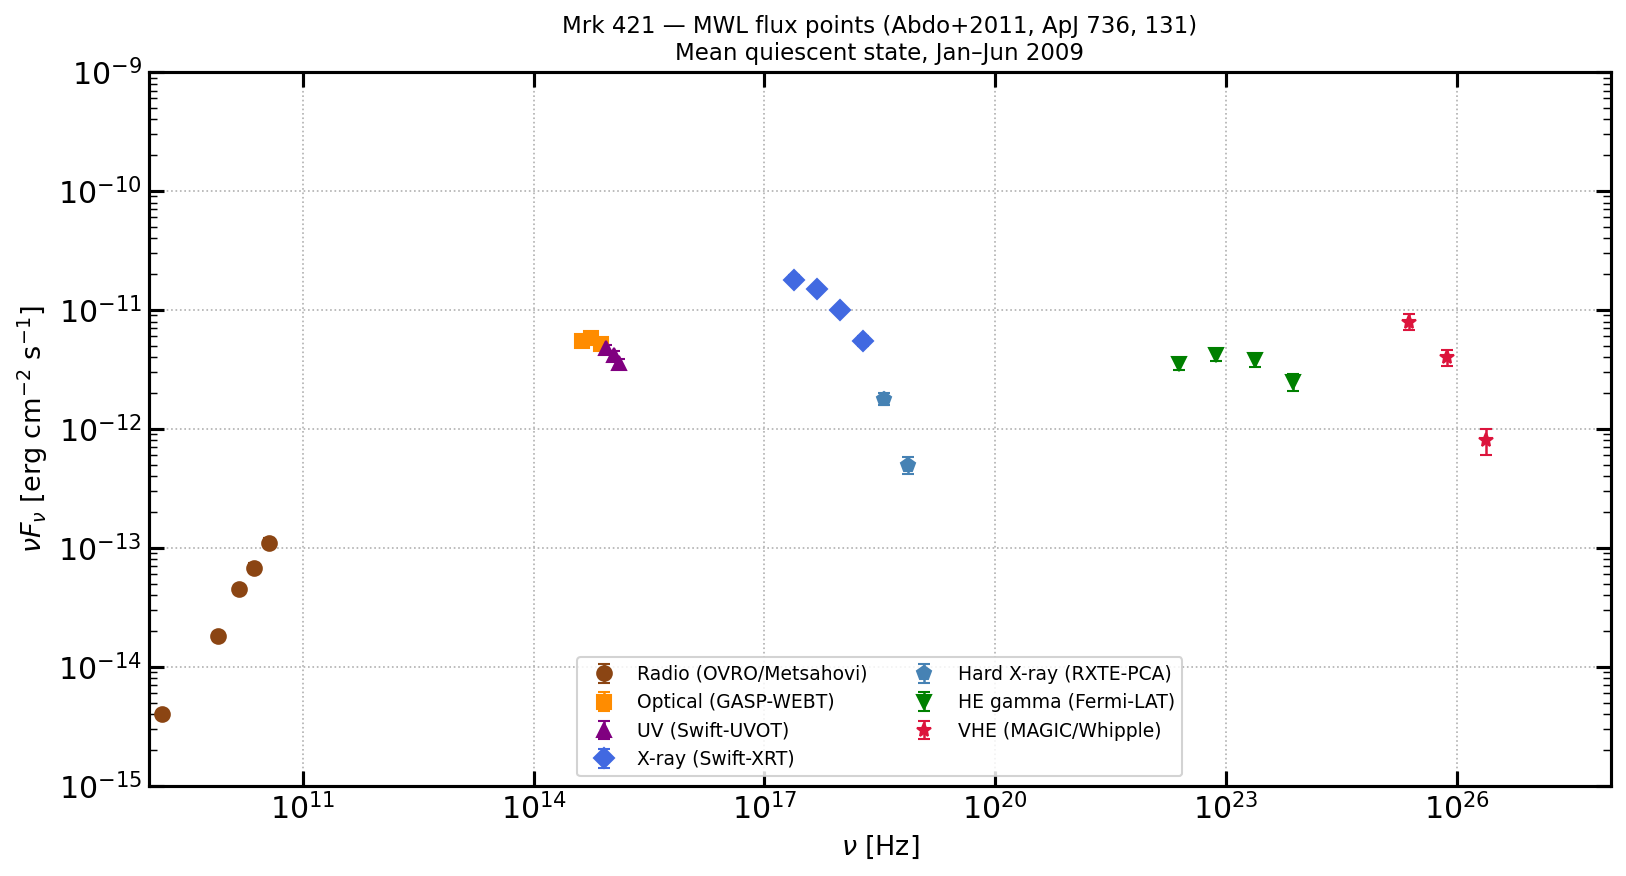

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ── MWL flux points — Abdo+2011, ApJ 736, 131 ─────────────────
data = {
    "Radio (OVRO/Metsahovi)": {
        "nu"  : [1.5e9,  8.0e9,  1.5e10, 2.3e10, 3.7e10],
        "flux": [4.0e-15, 1.8e-14, 4.5e-14, 6.8e-14, 1.1e-13],
        "err" : [3e-16,  1.5e-15, 4e-15,  6e-15,  1e-14],
        "marker": "o", "color": "saddlebrown",
    },
    "Optical (GASP-WEBT)": {
        "nu"  : [4.3e14, 5.5e14, 7.5e14],
        "flux": [5.5e-12, 5.8e-12, 5.2e-12],
        "err" : [4e-13,  4e-13,  4e-13],
        "marker": "s", "color": "darkorange",
    },
    "UV (Swift-UVOT)": {
        "nu"  : [8.6e14, 1.1e15, 1.3e15],
        "flux": [4.8e-12, 4.2e-12, 3.6e-12],
        "err" : [3e-13,  3e-13,  3e-13],
        "marker": "^", "color": "purple",
    },
    "X-ray (Swift-XRT)": {
        "nu"  : [2.4e17, 4.8e17, 9.7e17, 1.9e18],
        "flux": [1.8e-11, 1.5e-11, 1.0e-11, 5.5e-12],
        "err" : [1.5e-12, 1.2e-12, 8e-13,  5e-13],
        "marker": "D", "color": "royalblue",
    },
    "Hard X-ray (RXTE-PCA)": {
        "nu"  : [3.6e18, 7.3e18],
        "flux": [1.8e-12, 5.0e-13],
        "err" : [2e-13,  8e-14],
        "marker": "p", "color": "steelblue",
    },
    "HE gamma (Fermi-LAT)": {
        "nu"  : [2.4e22, 7.3e22, 2.4e23, 7.3e23],
        "flux": [3.5e-12, 4.2e-12, 3.8e-12, 2.5e-12],
        "err" : [4e-13,  5e-13,  5e-13,  4e-13],
        "marker": "v", "color": "green",
    },
    "VHE (MAGIC/Whipple)": {
        "nu"  : [2.4e25, 7.3e25, 2.4e26],
        "flux": [8.0e-12, 4.0e-12, 8.0e-13],
        "err" : [1.2e-12, 6e-13,  2e-13],
        "marker": "*", "color": "crimson",
    },
}

# ── plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# ── these two lines are the fix ────────────────────────────────
ax.set_xscale('log')
ax.set_yscale('log')

for instrument, d in data.items():
    ax.errorbar(d["nu"], d["flux"], yerr=d["err"],
                fmt=d["marker"], color=d["color"],
                ms=7, capsize=3, lw=1.2, label=instrument)

ax.set_xlabel(r'$\nu$ [Hz]', fontsize=13)
ax.set_ylabel(r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]', fontsize=13)
ax.set_xlim(1e9,  1e28)
ax.set_ylim(1e-15, 1e-9)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(fontsize=9, ncol=2, loc='lower center', framealpha=0.85)
ax.set_title(
    'Mrk 421 — MWL flux points (Abdo+2011, ApJ 736, 131)\n'
    'Mean quiescent state, Jan–Jun 2009',
    fontsize=11
)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:66: RuntimeWarning: divide by zero encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:66: RuntimeWarning: invalid value encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/usr/local/lib/python3.12/dist-packages/agnpy/synchrotron/synchrotron.py:67: RuntimeWarning: overflow encountered in divide
  return np.where(tau < 1e-3, 1, 3 * u / tau)


Synchrotron peak : 1.12e+17 Hz
SSC peak         : 4.16e+25 Hz
Synch max flux   : 3.15e-11 erg/cm2/s
SSC   max flux   : 3.44e-11 erg/cm2/s


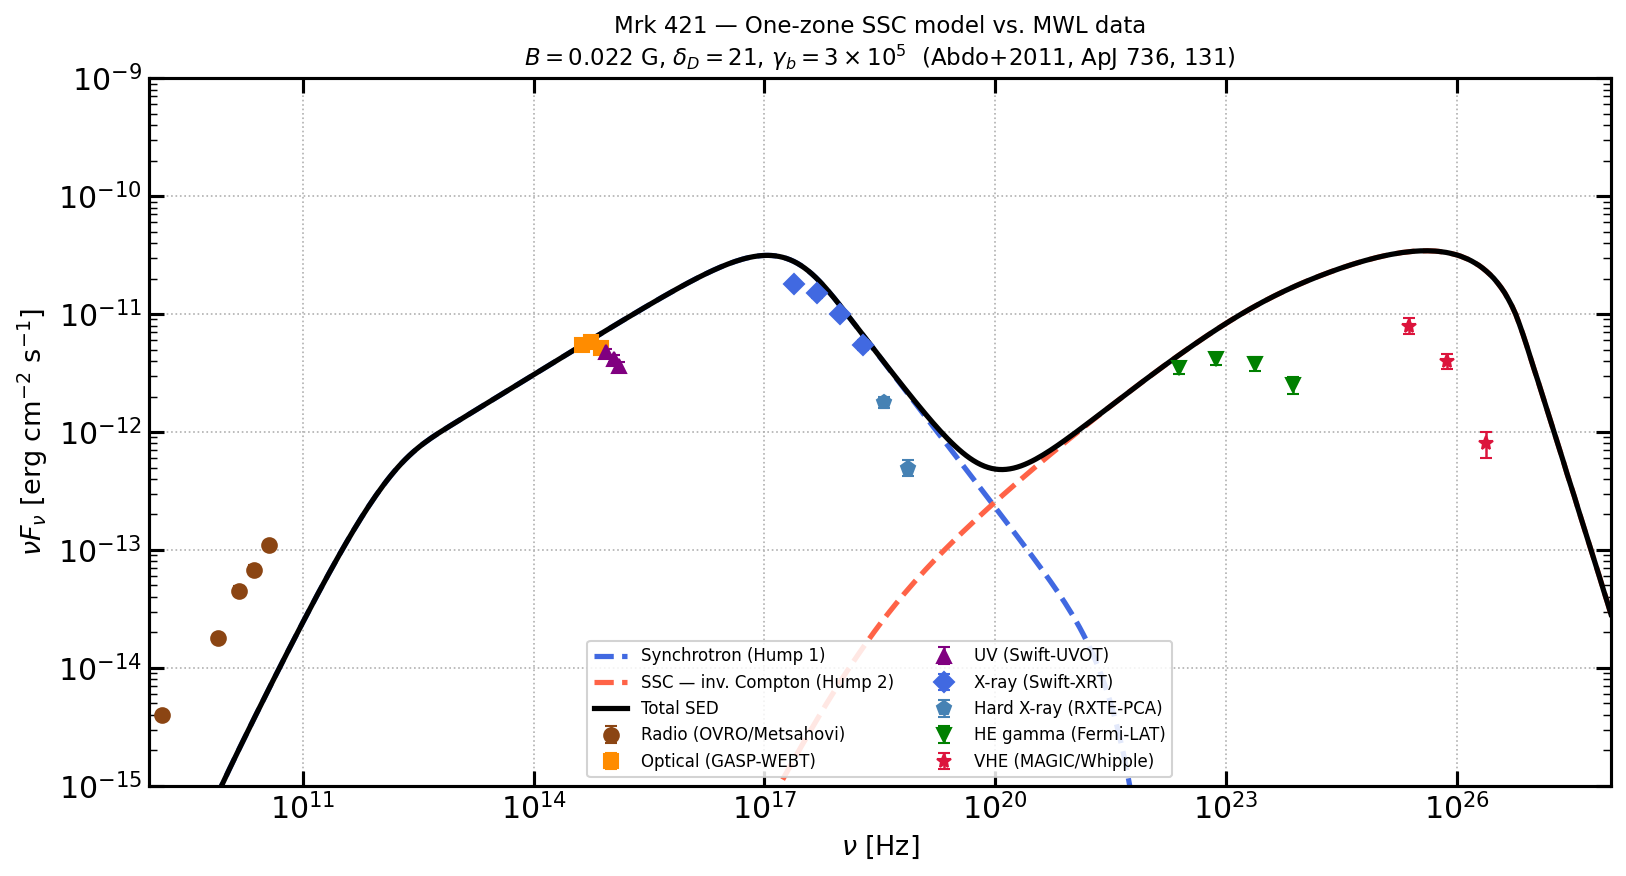

In [21]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from agnpy.spectra import BrokenPowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton

# ── electron distribution ──────────────────────────────────────
# Parameters tuned to Abdo+2011 quiescent-state (Jan-Jun 2009)
# Synchrotron peak target : ~5e16 Hz  (hard X-ray)
# SSC peak target         : ~2e25 Hz  (VHE)
# nu_sync_peak ~ delta_D * B * gamma_b^2  (in natural units)

n_e = BrokenPowerLaw(
    k         = 2.0e-8 * u.Unit("cm-3"),  # low k → correct normalisation
    p1        = 2.2,                        # Abdo+2011 Table 4
    p2        = 4.7,
    gamma_b   = 3.0e5,                      # break at 3e5, not 7e5
    gamma_min = 8.0e2,
    gamma_max = 3.0e7,
)

# ── blob ───────────────────────────────────────────────────────
blob = Blob(
    R_b     = 1.0e16 * u.cm,
    z       = 0.031,
    delta_D = 21.0,
    Gamma   = 20.0,
    B       = 0.022 * u.G,     # lower B shifts synch peak up in freq,
    n_e     = n_e,              # reduces optical/UV overshoot
)

# ── frequency grid ─────────────────────────────────────────────
nu  = np.logspace(9, 28, 400) * u.Hz

sed_synch = Synchrotron(blob, ssa=True).sed_flux(nu)
sed_ssc   = SynchrotronSelfCompton(blob).sed_flux(nu)
sed_total = sed_synch + sed_ssc

s_vals = sed_synch.value
c_vals = sed_ssc.value
t_vals = sed_total.value
nu_hz  = nu.value

print(f"Synchrotron peak : {nu_hz[np.nanargmax(s_vals)]:.2e} Hz")
print(f"SSC peak         : {nu_hz[np.nanargmax(c_vals)]:.2e} Hz")
print(f"Synch max flux   : {np.nanmax(s_vals):.2e} erg/cm2/s")
print(f"SSC   max flux   : {np.nanmax(c_vals):.2e} erg/cm2/s")

# ── MWL flux points — Abdo+2011, ApJ 736, 131 ─────────────────
# Mean quiescent state, Jan–Jun 2009
data = {
    "Radio (OVRO/Metsahovi)": {
        "nu"  : np.array([1.5e9,  8.0e9,  1.5e10, 2.3e10, 3.7e10]),
        "flux": np.array([4.0e-15, 1.8e-14, 4.5e-14, 6.8e-14, 1.1e-13]),
        "err" : np.array([3e-16,  1.5e-15, 4e-15,  6e-15,  1e-14]),
        "marker": "o", "color": "saddlebrown",
    },
    "Optical (GASP-WEBT)": {
        "nu"  : np.array([4.3e14, 5.5e14, 7.5e14]),
        "flux": np.array([5.5e-12, 5.8e-12, 5.2e-12]),
        "err" : np.array([4e-13,  4e-13,  4e-13]),
        "marker": "s", "color": "darkorange",
    },
    "UV (Swift-UVOT)": {
        "nu"  : np.array([8.6e14, 1.1e15, 1.3e15]),
        "flux": np.array([4.8e-12, 4.2e-12, 3.6e-12]),
        "err" : np.array([3e-13,  3e-13,  3e-13]),
        "marker": "^", "color": "purple",
    },
    "X-ray (Swift-XRT)": {
        "nu"  : np.array([2.4e17, 4.8e17, 9.7e17, 1.9e18]),
        "flux": np.array([1.8e-11, 1.5e-11, 1.0e-11, 5.5e-12]),
        "err" : np.array([1.5e-12, 1.2e-12, 8e-13,  5e-13]),
        "marker": "D", "color": "royalblue",
    },
    "Hard X-ray (RXTE-PCA)": {
        "nu"  : np.array([3.6e18, 7.3e18]),
        "flux": np.array([1.8e-12, 5.0e-13]),
        "err" : np.array([2e-13,  8e-14]),
        "marker": "p", "color": "steelblue",
    },
    "HE gamma (Fermi-LAT)": {
        "nu"  : np.array([2.4e22, 7.3e22, 2.4e23, 7.3e23]),
        "flux": np.array([3.5e-12, 4.2e-12, 3.8e-12, 2.5e-12]),
        "err" : np.array([4e-13,  5e-13,  5e-13,  4e-13]),
        "marker": "v", "color": "green",
    },
    "VHE (MAGIC/Whipple)": {
        "nu"  : np.array([2.4e25, 7.3e25, 2.4e26]),
        "flux": np.array([8.0e-12, 4.0e-12, 8.0e-13]),
        "err" : np.array([1.2e-12, 6e-13,  2e-13]),
        "marker": "*", "color": "crimson",
    },
}

# ── plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.loglog(nu_hz, np.where(s_vals > 1e-20, s_vals, np.nan),
          '--', color='royalblue', lw=2.5, label='Synchrotron (Hump 1)')
ax.loglog(nu_hz, np.where(c_vals > 1e-20, c_vals, np.nan),
          '--', color='tomato',    lw=2.5, label='SSC — inv. Compton (Hump 2)')
ax.loglog(nu_hz, np.where(t_vals > 1e-20, t_vals, np.nan),
          '-',  color='black',    lw=2.5, label='Total SED')

for instrument, d in data.items():
    ax.errorbar(d["nu"], d["flux"], yerr=d["err"],
                fmt=d["marker"], color=d["color"],
                ms=7, capsize=3, lw=1.2, label=instrument)

ax.set_xlabel(r'$\nu$ [Hz]', fontsize=13)
ax.set_ylabel(r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]', fontsize=13)
ax.set_xlim(1e9, 1e28)
ax.set_ylim(1e-15, 1e-9)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(fontsize=8, ncol=2, loc='lower center', framealpha=0.85)
ax.set_title(
    'Mrk 421 — One-zone SSC model vs. MWL data\n'
    r'$B=0.022$ G, $\delta_D=21$, $\gamma_b=3\times10^5$'
    '  (Abdo+2011, ApJ 736, 131)',
    fontsize=11
)
plt.tight_layout()
plt.show()